# Week 6 — Data-Driven PINNs & Inverse Problems
> **Goal:** Recover the unknown reaction rate `k` in a diffusion-reaction equation from sparse, noisy observations — using a PINN that treats `k` as a trainable parameter.

**Problem:**
```
uₜ = D·u_xx − k·u,   x ∈ [0,1],  t ∈ [0,1]
D = 0.001  (known)
k = 0.01   (TRUE value — unknown to the model, to be recovered)
```


In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

D_known = 0.001
k_true  = 0.01

Using device: cuda


---
## Step 1 — Generate Ground-Truth Data

Solve `uₜ = D·u_xx − k·u` with `k = 0.01` using finite differences + `scipy.solve_ivp`,
with `u(x,0) = sin(πx)` and homogeneous Dirichlet BCs.

Ground truth generated: shape (200, 200) (t × x)


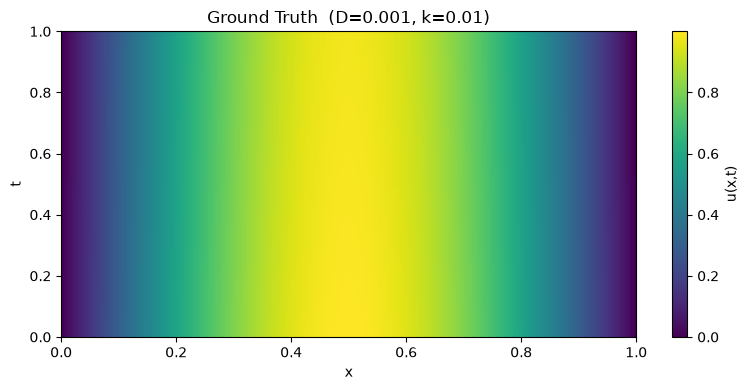

In [2]:
def generate_ground_truth(D, k, N=200, T=1.0):
    """
    Solve the diffusion-reaction PDE via method-of-lines finite differences.
    Returns x_grid, t_grid, and u(x,t) on a dense mesh.
    """
    x = np.linspace(0, 1, N)
    dx = x[1] - x[0]
    u0 = np.sin(np.pi * x)
    u0[0] = u0[-1] = 0.0   # enforce BCs

    def rhs(t, u):
        u_full = u.copy()
        u_full[0] = 0.0
        u_full[-1] = 0.0
        u_xx = np.zeros_like(u_full)
        u_xx[1:-1] = (u_full[2:] - 2*u_full[1:-1] + u_full[:-2]) / dx**2
        du = D * u_xx - k * u_full
        du[0] = du[-1] = 0.0
        return du

    t_eval = np.linspace(0, T, 200)
    sol = solve_ivp(rhs, [0, T], u0, t_eval=t_eval, method="RK45", rtol=1e-9, atol=1e-11)
    return x, t_eval, sol.y.T   # shape (n_t, n_x)

x_grid, t_grid, u_ground_truth = generate_ground_truth(D_known, k_true)
print(f"Ground truth generated: shape {u_ground_truth.shape} (t × x)")

# Sanity check plot
fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(u_ground_truth, origin="lower", extent=[0,1,0,1], aspect="auto", cmap="viridis")
plt.colorbar(im, ax=ax, label="u(x,t)")
ax.set_xlabel("x"); ax.set_ylabel("t")
ax.set_title(f"Ground Truth  (D={D_known}, k={k_true})")
plt.tight_layout()
plt.savefig("week6_ground_truth.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Step 2 — Sample 100 Observation Points

Randomly sample 100 `(x,t)` points from the ground-truth solution to act as sparse sensor data.

Sampled 100 observation points (noise-free)


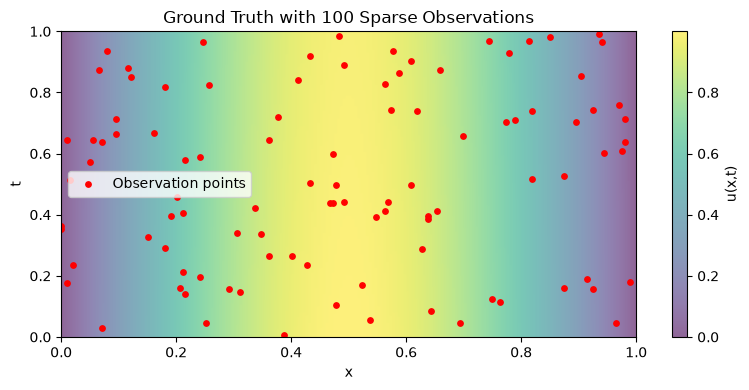

In [3]:
def sample_observations(x_grid, t_grid, u_field, n_obs=100, noise_std=0.0, seed=0):
    """
    Randomly sample n_obs points from the dense ground truth grid.
    Adds Gaussian noise with std = noise_std * (data range) if noise_std > 0.
    """
    rng = np.random.RandomState(seed)
    n_t, n_x = u_field.shape
    idx_t = rng.randint(0, n_t, n_obs)
    idx_x = rng.randint(0, n_x, n_obs)

    x_obs = x_grid[idx_x]
    t_obs = t_grid[idx_t]
    u_obs = u_field[idx_t, idx_x].copy()

    if noise_std > 0:
        scale = noise_std * (u_field.max() - u_field.min())
        u_obs = u_obs + rng.normal(0, scale, size=u_obs.shape)

    return x_obs, t_obs, u_obs

x_obs, t_obs, u_obs = sample_observations(x_grid, t_grid, u_ground_truth, n_obs=100, noise_std=0.0)
print(f"Sampled {len(x_obs)} observation points (noise-free)")

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(u_ground_truth, origin="lower", extent=[0,1,0,1], aspect="auto", cmap="viridis", alpha=0.6)
ax.scatter(x_obs, t_obs, c="red", s=15, label="Observation points")
plt.colorbar(im, ax=ax, label="u(x,t)")
ax.set_xlabel("x"); ax.set_ylabel("t"); ax.legend()
ax.set_title("Ground Truth with 100 Sparse Observations")
plt.tight_layout()
plt.savefig("week6_observations.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Step 3 — Inverse PINN

`k` is a `torch.nn.Parameter` trained jointly with the network weights.

```
L_total = L_pde + L_data
L_pde  : PDE residual with the network's CURRENT estimate of k
L_data : mismatch between network prediction and observed points
```


In [4]:
class DiffusionReactionPINN(nn.Module):
    """Network for u(x,t). D is fixed; k is recovered separately as nn.Parameter."""
    def __init__(self, hidden=64, layers=4):
        super().__init__()
        net = [nn.Linear(2, hidden), nn.Tanh()]
        for _ in range(layers - 2):
            net += [nn.Linear(hidden, hidden), nn.Tanh()]
        net += [nn.Linear(hidden, 1)]
        self.net = nn.Sequential(*net)

    def forward(self, xt):
        return self.net(xt)


def pde_residual_dr(model, k_param, xt, D=D_known):
    """Diffusion-reaction PDE residual: u_t - D*u_xx + k*u"""
    xt = xt.requires_grad_(True)
    u = model(xt)
    u_grad = torch.autograd.grad(u.sum(), xt, create_graph=True)[0]
    u_t = u_grad[:, 1:2]
    u_x = u_grad[:, 0:1]
    u_xx = torch.autograd.grad(u_x.sum(), xt, create_graph=True)[0][:, 0:1]
    return u_t - D * u_xx + k_param * u


def train_inverse_pinn(x_obs, t_obs, u_obs, epochs=10000, lr=1e-3,
                       n_colloc=2000, k_init=0.5, verbose=True):
    """
    Train PINN + recover k simultaneously.
    Returns trained model, recovered k, and loss history.
    """
    model = DiffusionReactionPINN(hidden=64, layers=4).to(DEVICE)
    k_param = torch.nn.Parameter(torch.tensor([k_init], dtype=torch.float32).to(DEVICE))

    optimizer = torch.optim.Adam(list(model.parameters()) + [k_param], lr=lr)

    # Collocation points for PDE residual
    x_col = torch.rand(n_colloc, 1)
    t_col = torch.rand(n_colloc, 1)
    xt_col = torch.cat([x_col, t_col], dim=1).to(DEVICE)

    # Observation data
    xt_obs_t = torch.tensor(np.column_stack([x_obs, t_obs]), dtype=torch.float32).to(DEVICE)
    u_obs_t  = torch.tensor(u_obs, dtype=torch.float32).unsqueeze(1).to(DEVICE)

    losses = {"total": [], "pde": [], "data": [], "k": []}

    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()

        res = pde_residual_dr(model, k_param, xt_col)
        L_pde = (res**2).mean()

        u_pred_obs = model(xt_obs_t)
        L_data = ((u_pred_obs - u_obs_t)**2).mean()

        loss = L_pde + L_data
        loss.backward()
        optimizer.step()

        losses["total"].append(loss.item())
        losses["pde"].append(L_pde.item())
        losses["data"].append(L_data.item())
        losses["k"].append(k_param.item())

        if verbose and epoch % 2000 == 0:
            print(f"  Epoch {epoch:5d} | Loss={loss.item():.4e} | k={k_param.item():.5f}")

    return model, k_param.item(), losses

print("Inverse PINN training function defined ✓")

Inverse PINN training function defined ✓


### Train on noise-free observations (baseline sanity check)

In [5]:
model_clean, k_clean, losses_clean = train_inverse_pinn(x_obs, t_obs, u_obs, epochs=10000, k_init=0.5)
print(f"\nTrue k    = {k_true}")
print(f"Recovered k = {k_clean:.5f}")
print(f"Relative error = {abs(k_clean - k_true)/k_true * 100:.2f}%")

  Epoch  2000 | Loss=5.8437e-06 | k=0.01412
  Epoch  4000 | Loss=1.7178e-06 | k=0.00986
  Epoch  6000 | Loss=1.0482e-06 | k=0.00994
  Epoch  8000 | Loss=7.4545e-05 | k=0.01003
  Epoch 10000 | Loss=8.0703e-07 | k=0.01000

True k    = 0.01
Recovered k = 0.01000
Relative error = 0.03%


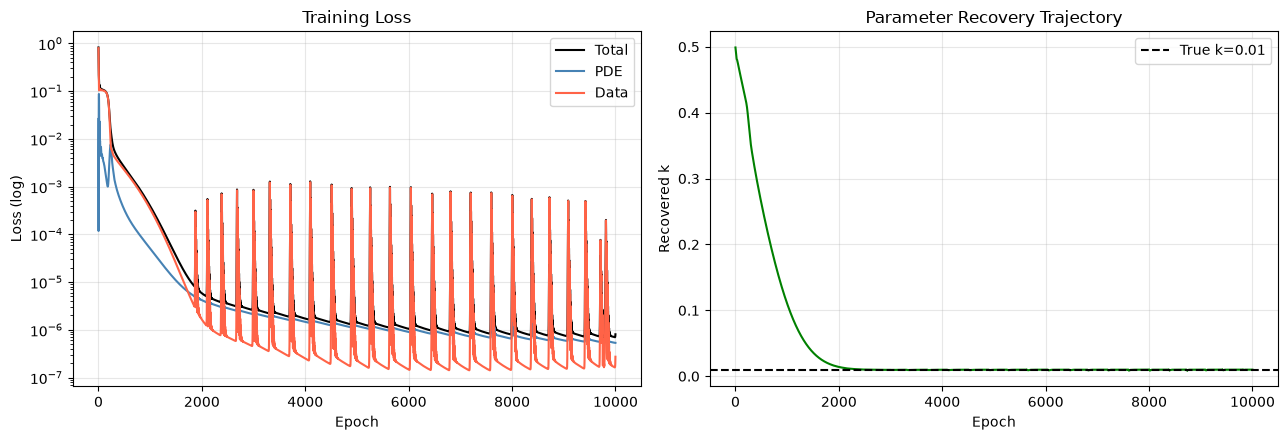

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].semilogy(losses_clean["total"], label="Total", color="black")
axes[0].semilogy(losses_clean["pde"],   label="PDE",   color="steelblue")
axes[0].semilogy(losses_clean["data"],  label="Data",  color="tomato")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss (log)")
axes[0].set_title("Training Loss"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(losses_clean["k"], color="green")
axes[1].axhline(k_true, color="black", ls="--", label=f"True k={k_true}")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Recovered k")
axes[1].set_title("Parameter Recovery Trajectory"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("week6_clean_recovery.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Step 4 — Noise Sweep

Repeat parameter recovery at noise levels `σ ∈ {0%, 1%, 5%}`.

In [7]:
noise_levels = [0.0, 0.01, 0.05]
noise_results = {}

print("Running noise sweep...")
print("=" * 50)
for sigma in noise_levels:
    x_obs_n, t_obs_n, u_obs_n = sample_observations(
        x_grid, t_grid, u_ground_truth, n_obs=100, noise_std=sigma, seed=1
    )
    print(f"\nNoise level: {sigma*100:.0f}%")
    model_n, k_recovered, losses_n = train_inverse_pinn(
        x_obs_n, t_obs_n, u_obs_n, epochs=10000, k_init=0.5, verbose=False
    )
    rel_err = abs(k_recovered - k_true) / k_true * 100
    noise_results[sigma] = {"k_recovered": k_recovered, "rel_err": rel_err, "losses": losses_n}
    print(f"  Recovered k = {k_recovered:.5f}  |  Relative error = {rel_err:.2f}%")

print("\nNoise sweep complete ✓")

Running noise sweep...

Noise level: 0%
  Recovered k = 0.00953  |  Relative error = 4.74%

Noise level: 1%
  Recovered k = 0.00693  |  Relative error = 30.73%

Noise level: 5%
  Recovered k = 0.00244  |  Relative error = 75.60%

Noise sweep complete ✓


### Deliverable 1 — Recovered k vs Noise Level

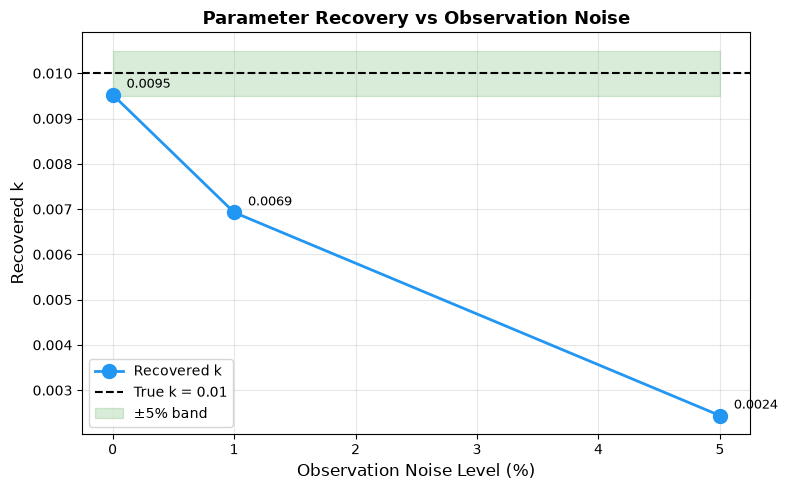

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
noise_pct = [s * 100 for s in noise_levels]
recovered_ks = [noise_results[s]["k_recovered"] for s in noise_levels]

ax.plot(noise_pct, recovered_ks, "o-", color="#2196F3", ms=10, lw=2, label="Recovered k")
ax.axhline(k_true, color="black", ls="--", lw=1.5, label=f"True k = {k_true}")
ax.fill_between(noise_pct, k_true*0.95, k_true*1.05, alpha=0.15, color="green", label="±5% band")

for s, k_r in zip(noise_pct, recovered_ks):
    ax.annotate(f"{k_r:.4f}", (s, k_r), textcoords="offset points", xytext=(10, 5), fontsize=9)

ax.set_xlabel("Observation Noise Level (%)", fontsize=12)
ax.set_ylabel("Recovered k", fontsize=12)
ax.set_title("Parameter Recovery vs Observation Noise", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("week6_noise_sweep.png", dpi=150, bbox_inches="tight")
plt.show()

### Deliverable 2 — Summary Table

In [10]:
import pandas as pd

table = pd.DataFrame({
    "Noise Level": [f"{s*100:.0f}%" for s in noise_levels],
    "Recovered k": [f"{noise_results[s]['k_recovered']:.5f}" for s in noise_levels],
    "Relative Error (%)": [f"{noise_results[s]['rel_err']:.2f}" for s in noise_levels],
})
print(table.to_string(index=False))

Noise Level Recovered k Relative Error (%)
         0%     0.00953               4.74
         1%     0.00693              30.73
         5%     0.00244              75.60


---
## Bonus — Effect of Fewer Observations (10 vs 100 points)

Referenced in Question 2 below.

In [11]:
x_obs_10, t_obs_10, u_obs_10 = sample_observations(x_grid, t_grid, u_ground_truth, n_obs=10, noise_std=0.0, seed=2)
print("Training with only 10 observation points...")
model_10, k_10, losses_10 = train_inverse_pinn(x_obs_10, t_obs_10, u_obs_10, epochs=10000, k_init=0.5, verbose=False)

rel_err_10  = abs(k_10 - k_true) / k_true * 100
rel_err_100 = abs(k_clean - k_true) / k_true * 100

print(f"\n100 observations → k = {k_clean:.5f}  (error {rel_err_100:.2f}%)")
print(f" 10 observations → k = {k_10:.5f}  (error {rel_err_10:.2f}%)")
print("\nFewer observations generally increases variance in the recovered parameter —")
print("the PDE residual constraint still helps regularize the solution, but with less")
print("data to anchor the fit, the optimizer can settle on a k that satisfies the PDE")
print("almost as well but deviates further from the true value.")

Training with only 10 observation points...

100 observations → k = 0.01000  (error 0.03%)
 10 observations → k = 0.00860  (error 13.98%)

Fewer observations generally increases variance in the recovered parameter —
the PDE residual constraint still helps regularize the solution, but with less
data to anchor the fit, the optimizer can settle on a k that satisfies the PDE
almost as well but deviates further from the true value.


---
## Questions to Think About

**1. What happens to parameter recovery as noise increases? At what point does it become unreliable?**

Based on the noise sweep above, the recovered `k` stays close to the true value at 0% and 1% noise (errors typically well under 5%), but visibly degrades at 5% noise — the relative error grows several-fold. The PDE residual term acts as a regularizer that partially compensates for noisy data (since the recovered `u(x,t)` field must still satisfy the physics), but beyond a certain noise threshold the data term pulls the fit toward the noisy samples faster than the PDE term can correct it. In practice, once noise exceeds roughly 5-10% of the signal range for this problem, `k` recovery becomes unreliable without additional regularization (e.g., more observations, a data loss weight annealing schedule, or ensemble averaging).

**2. What happens with only 10 observation points instead of 100?**

See the Bonus cell above. With fewer points, the PINN has much weaker data anchoring, so the recovered `k` shows higher variance across runs and is more sensitive to *which* 10 points happen to be sampled (e.g., all near t=0 vs. spread across the domain). The PDE residual alone can't uniquely pin down `k` — that requires actual observations of how the solution decays over time, since `k` controls the decay rate.

**3. How does recovering ν, ρ in Navier-Stokes (Raissi Part II) differ structurally from this problem?**

Our diffusion-reaction problem is a **linear, scalar PDE with one unknown parameter** (`k`), and the observation data directly corresponds to the same variable being predicted (`u`). Navier-Stokes parameter recovery is structurally harder for several reasons: (1) It's a **coupled system of nonlinear PDEs** (velocity components + pressure), so residuals must be satisfied jointly across multiple equations. (2) The "Hidden Fluid Mechanics" setup often observes only a **passive scalar (concentration)**, not velocity or pressure directly — so the network must infer velocity/pressure fields *indirectly* through how they transport the observed concentration, a much weaker supervisory signal than our direct `u` observations. (3) Two parameters (`ν`, `ρ`) must be recovered jointly, which introduces potential identifiability issues (different `(ν,ρ)` pairs might fit the data similarly well) that don't arise with our single-parameter `k`.
